In [319]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.io import loadmat as loadmat

In [320]:
rootfolder = '..'

Useful function for the plot

In [321]:
def display_band( X, par,epsi=0.001,col='k'):
    x1 = np.min(X[0, :])
    x2 = np.max(X[0, :])
    y1 = np.min(X[1, :])
    y2 = np.max(X[1, :])

    # extend the line for the k# of its lenght 
    k = 0.01
    dx = x2-x1
    dy = y2-y1
    l = np.sqrt(dx**2+dy**2)
    x1 = x1 - k*l
    x2 = x2 + k*l
    y1 = y1 - k*l
    y2 = y2 + k*l
    
    if np.abs(par[1])<2e-2 :
        #disp('vertical line')
        a = np.vstack([-(par[1]*y1 + par[2])/par[0], y1])
        b = np.vstack([-(par[1]*y2 + par[2])/par[0], y2])
    else:
        a = np.vstack([x1, -(par[0]*x1 + par[2])/par[1]])
        b = np.vstack([x2, -(par[0]*x2 + par[2])/par[1]])

    if np.abs(par[0])<1e-5:
        v = np.array([0,1]) 
    else:    
        v = np.array([1, par[1]/par[0]]) # direction perpendicular to the line;

    v = v / np.sqrt(np.sum(v**2))
    # corners of the bands
    v = v[:, np.newaxis]
    a1 = a - epsi * v
    a2 = a + epsi * v
    b1 = b - epsi * v
    b2 = b + epsi * v

    px = np.array([a1[0], b1[0], b2[0], a2[0]]).squeeze()
    py = np.array([a1[1], b1[1], b2[1], a2[1]]).squeeze()
    plt.tricontourf(px,py,np.ones_like(px), colors=col,alpha=0.5)
    plt.gca().set_aspect('equal')

def display_clust(X, G, cmap):
    G = np.asarray(G, dtype=int)
    switch_out = 1
    smb = 'o'
    col = []
    num_clust = int(np.max(G))

    for i in range(1, num_clust+1):
        id = G == i
        id = id.squeeze()
        x = X[0, id]
        y = X[1, id]
        if len(col) == 0:
            plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
        else:
            plt.scatter(x,y,50,col,marker=smb,edgecolors=col, alpha=0.1)
        if switch_out == 1:
            id = G == 0
            id = id.squeeze()
            plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)

Function that computes the residual between points and a line

In [322]:
def res_line(X, M):
    if len(M.shape) > 1:
        num_lines = M.shape[1]
    else:
        num_lines = 1

    if num_lines == 1:
        d = np.abs(M[0] * X[0, :] + M[1] * X[1, :] + M[2])
    else:
        n = X.shape[1]
        d = np.zeros((n, num_lines))
        for i in range(num_lines):
            d[:, i] = np.abs(M[0, i] * X[0, :] + M[1, i] * X[1, :] + M[2, i])

Functions to add outlier to the dataset

In [323]:
# def addOutliersInBB(X, nOutliers, k=0.1):
#     xmin = np.min(X[0, :])
#     xmax = np.max(X[0, :])
#     ymin = np.min(X[1, :])
#     ymax = np.max(X[1, :])
#     wx = xmax-xmin
#     wy = ymax -ymin
#     dx = k*wx
#     dy = k*wy

#     Y = np.hstack((
#         X,
#         np.vstack((
#             xmax-xmin+2*dx * np.random.uniform(size=(1, nOutliers)) + xmin-dx,
#             ymax-ymin+2*dy * np.random.uniform(size=(1, nOutliers)) + ymin-dy
#         ))
#     ))
#     return Y

# new version
def addOutliersInBB(X, nOutliers, k=0.1):
    xmin = np.min(X[0, :])
    xmax = np.max(X[0, :])
    ymin = np.min(X[1, :])
    ymax = np.max(X[1, :])

    wx = xmax - xmin
    wy = ymax - ymin

    dx = k * wx
    dy = k * wy

    x_out = (wx + 2*dx) * np.random.uniform(size=(1, nOutliers)) + xmin - dx
    y_out = (wy + 2*dy) * np.random.uniform(size=(1, nOutliers)) + ymin - dy

    Y = np.hstack((X, np.vstack((x_out, y_out))))

    return Y

Ransac
------
Use the implementation from the last lecture

In [324]:
def fit_line_dlt(P):
    # design matrix
    A = np.column_stack((P[:, 0], P[:, 1], np.ones_like(P[:, 0])))
    
    # SVD
    _, _, VT = np.linalg.svd(A, full_matrices=True)
    
    theta = VT.T[:, -1]
    
    residuals = A @ theta   
    residual_error = np.sum(residuals ** 2)
    
    return theta, residuals, residual_error

In [325]:
def simpleRANSAC(X, eps, cardmss=2):
    # number of samples in the dataset
    n = X.shape[1] 
    
    # desired probability of success
    alpha = 0.99 

    # pessimistic estimate of inliers fraction
    f = 0.5
    # probability of being outlier
    e = 1 - f

    # set maximum number of iterations
    maxIterations = int(np.ceil(np.log(1 - alpha) / np.log(1 - (1 - e) ** cardmss)))

    # set maximum consensus reached
    maxscore = -np.inf
    
    for k in range(maxIterations):
        # generate cardmss random indices in the range 0 ... (N-1)
        mss_k = np.random.choice(n, size=cardmss, replace=False)
        
        # fit model to this minimal sample set
        theta_k, _, _ = fit_line_dlt(X[:, mss_k].T)

        # evaluate distances between points and model
        sqres = (theta_k[0] * X[0, :] + theta_k[1] * X[1, :] + theta_k[2])**2 / (theta_k[0]**2 + theta_k[1]**2)

        # identify inliers: consensus set
        inliers = sqres < eps**2

        # assess consensus (the number of inliers)
        score = np.sum(inliers)

        # replace maxscore, bestinliers and bestmodel if needed
        if score > maxscore:
            maxscore = score
            bestinliers = inliers
            bestmodel = theta_k

    return bestmodel, bestinliers

Ransac implementation for circle fitting

In [326]:
def fit_circle_dlt(X):
    # design matrix
    A = np.column_stack((X[:, 0], X[:, 1], np.ones(X.shape[0])))
    B = X[:, 0]**2 + X[:, 1]**2

    # solve least squares problem
    theta_alg = np.linalg.lstsq(A, B, rcond=None)[0]
    a, b, c = theta_alg

    # convert algebraic parameters to geometric parameters
    cx = a / 2
    cy = b / 2

    r2 = c + cx**2 + cy**2

    r = np.sqrt(r2)

    theta = np.array([cx, cy, r])

    # geometric residuals
    residuals = np.sqrt((X[:, 0] - cx)**2 + (X[:, 1] - cy)**2) - r
    residual_error = np.sum(residuals**2)

    return theta, residuals, residual_error

In [327]:
def simpleRANSAC_circle(X, eps, cardmss=3):
    # number of samples in the dataset
    n = X.shape[1]

    # desired probability of success
    alpha = 0.99

    # pessimistic estimate of inliers fraction
    f = 0.5
    # probability of being outlier
    e = 1 - f

    # set maximum number of iterations
    maxIterations = int(np.ceil(np.log(1 - alpha) / np.log(1 - (1 - e) ** cardmss))) * 10

    # initialize best consensus
    maxscore = -np.inf
    
    for k in range(maxIterations):
        # generate cardmss random indices in the range 0 ... (N-1)
        mss_k = np.random.choice(n, size=cardmss, replace=False)

        # fit circle to minimal sample set
        theta_k, _, _ = fit_circle_dlt(X[:, mss_k].T)
        cx, cy, r = theta_k

        # evaluate geometric squared residuals
        sqres = (np.sqrt((X[0, :] - cx)**2 + (X[1, :] - cy)**2) - r)**2

        # identify inliers
        inliers = sqres < eps**2

        # assess consensus (the number of inliers)
        score = np.sum(inliers)

        # update best model
        if score > maxscore:
            maxscore = score
            bestinliers = inliers
            bestmodel = theta_k

    return bestmodel, bestinliers

## Sequential RANSAC on the Stair dataset

In [328]:
# inlier threshold for ransac
epsi = 0.02

temp = loadmat(f'{rootfolder}/data/stair4.mat')

# data
X = temp['X']
# ground truth or label (1: normal, 0: outlier)
G = temp['G']

# model specification
# functions to fit and compute residuals are already invoked in the function
cardmss = 2 # minimum number of points required to fit a model
kappa = 5 # number of models to be extracted by sequential ransac

# plotting params
bw = 0.01
col = 'b'
temp = loadmat(f'{rootfolder}/data/cmap.mat')
cmap = temp['cmap']

# add outliers
nOut = 10

# add outlier and update groundtruth
X = addOutliersInBB(X, nOut)

# update the label, considering that X previous command has appended nOut otliers 
G = np.hstack((G.flatten(), np.zeros(nOut))).reshape(1, -1)

C:\Users\nicco\AppData\Local\Temp\ipykernel_7960\2377814344.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
C:\Users\nicco\AppData\Local\Temp\ipykernel_7960\2377814344.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


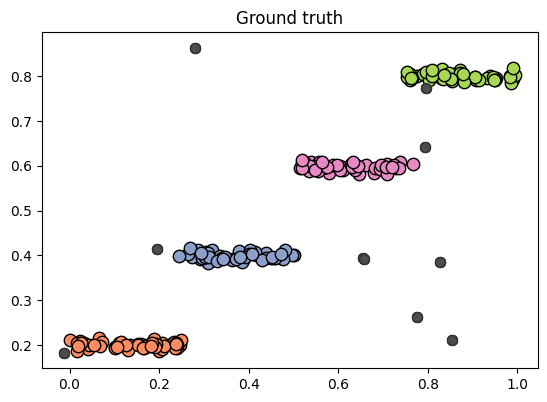

In [329]:
plt.figure(1)
display_clust(X,G, cmap)
plt.title('Ground truth')
plt.gca().set_aspect('equal')
plt.show()

Implement the sequential ransac algorithm

In [330]:
# take a copy of X to be modified
Y = X.copy()

# define cells to contain the fitted models
currentModel = []
currentInliers = []

# minimum number of expected inliers for each
E_min = 10

cnt = 0
while cnt < kappa and Y.shape[1] >= E_min:
    # find model with ransac (save currentModel and currentInliers for visualization)
    theta_k, inliers_k = simpleRANSAC(Y, epsi, cardmss)

    # stopping criterion based on the consensus of the last model found
    if np.sum(inliers_k) < E_min:
        print("Not enough inliers found, stopping at iteration", cnt)
        break

    # save current model
    currentModel.append(theta_k)
    # save current inliers
    currentInliers.append(inliers_k)

    # remove current inliers
    Y = np.delete(Y, inliers_k, axis=1)

    # update iterations
    cnt += 1

    print("Model", cnt, "found with", np.sum(inliers_k), "inliers.")

    # additional stopping criterion based on remaining data
    if Y.shape[1] < E_min:
        print("Less than E_min points remaining, stopping.")
        break

Model 1 found with 61 inliers.
Model 2 found with 42 inliers.
Model 3 found with 48 inliers.
Model 4 found with 23 inliers.
Model 5 found with 17 inliers.


Show the iteration of Sequential Ransac

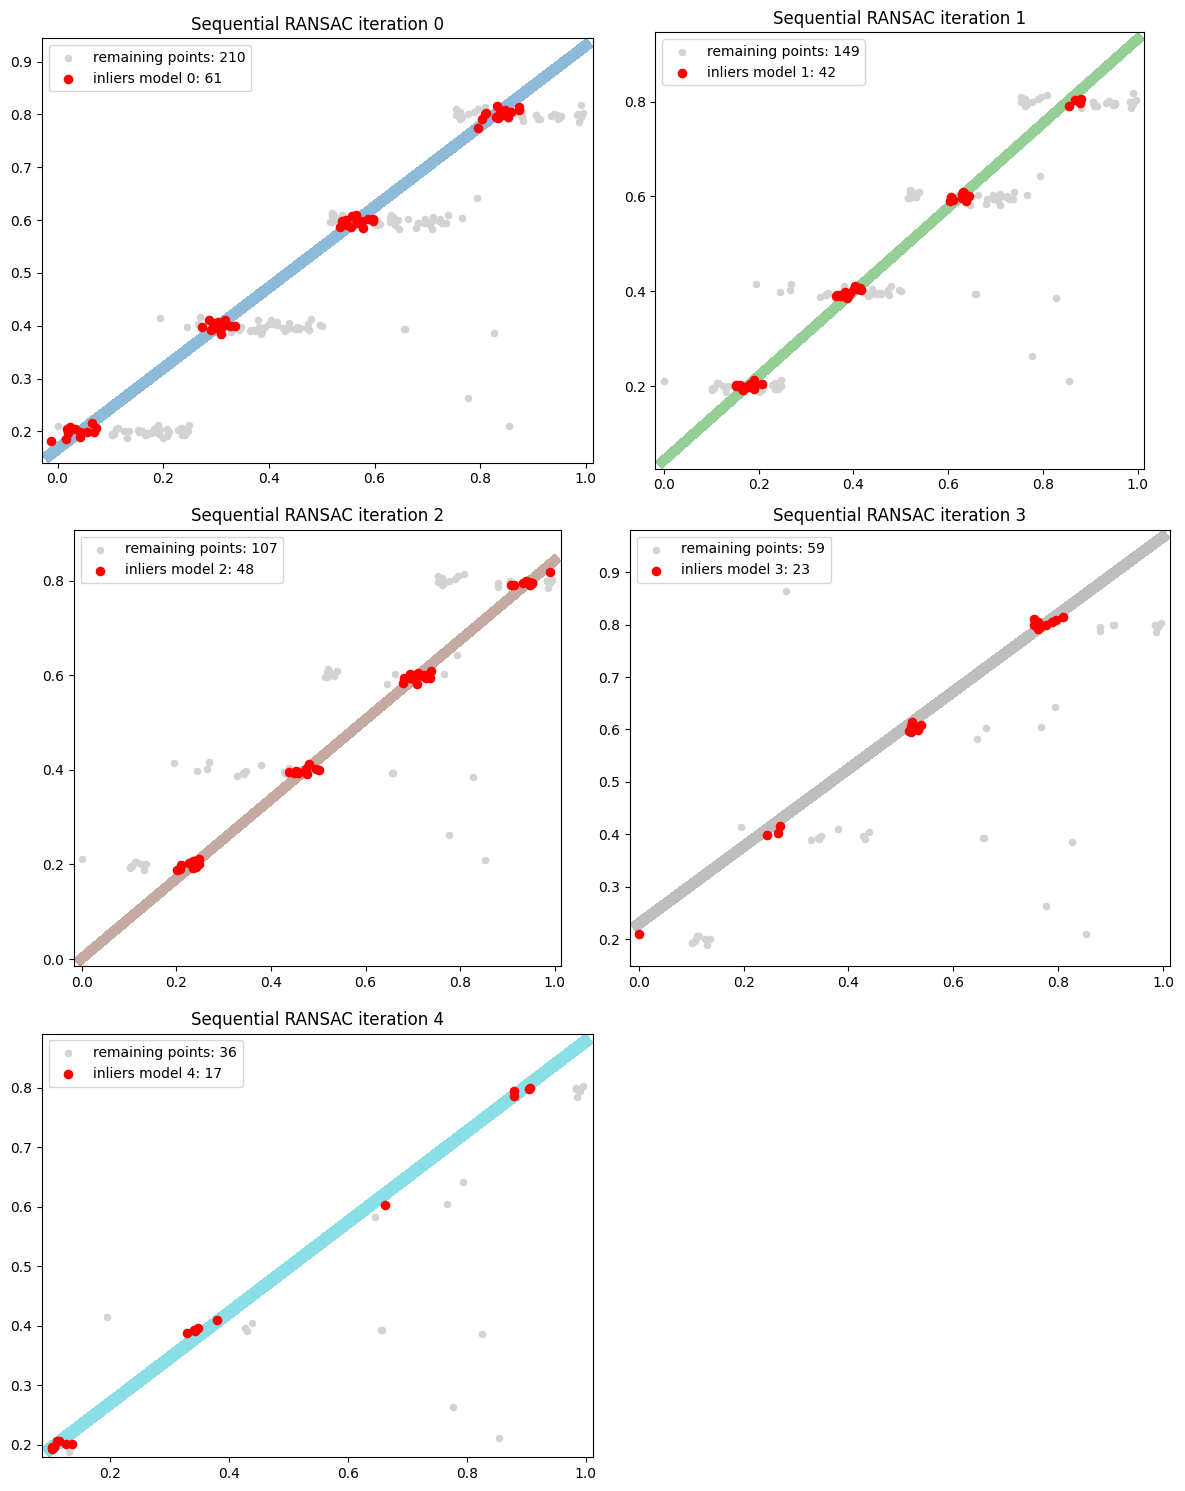

In [331]:
Y = X.copy()

# number of models actually found
n_models = len(currentModel)

# generate one color for each model
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

n_cols = 2
n_rows = int(np.ceil(kappa / n_cols))

plt.figure(figsize=(12, 5 * n_rows))

for i in range(n_models):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.gca().set_aspect('equal')

    # get current model and current inliers
    theta_i = currentModel[i]
    inliers_i = currentInliers[i]

    # color associated with current model
    color_i = colors[i]

    # plot remaining points before removing current inliers
    plt.scatter(
        Y[0, :],
        Y[1, :],
        c='lightgray',
        s=20,
        label=f'remaining points: {Y.shape[1]}'
    )

    # display a band for each model estimated
    display_band(Y, theta_i, bw, color_i)

    # plot inliers for this model
    plt.scatter(
        Y[0, inliers_i],
        Y[1, inliers_i],
        c='red',
        s=35,
        label=f'inliers model {i}: {np.sum(inliers_i)}'
    )

    plt.title(f'Sequential RANSAC iteration {i:d}')
    plt.legend(loc='upper left')

    # remove the inliers plotted from Y
    Y = np.delete(Y, inliers_i, axis=1)

# hide the unused subplot if kappa is odd
if kappa % n_cols != 0:
    plt.subplot(n_rows, n_cols, kappa + 1)
    plt.axis('off')

plt.tight_layout()
plt.show()

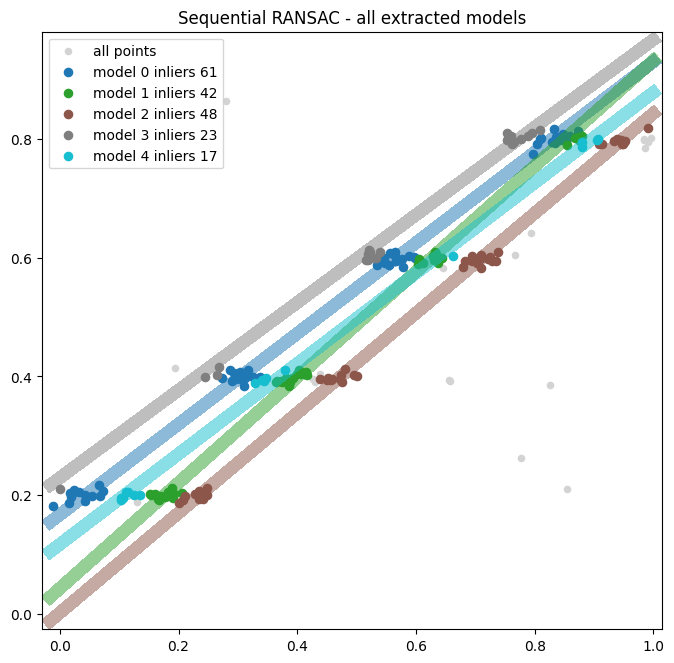

In [332]:
plt.figure(figsize=(8, 8))
plt.gca().set_aspect('equal')

# plot all original points in background
plt.scatter(
    X[0, :],
    X[1, :],
    c='lightgray',
    s=20,
    label='all points'
)

# mapping from current residual dataset Y to original dataset X
remaining_idx = np.arange(X.shape[1])

for i in range(n_models):
    theta_i = currentModel[i]
    inliers_i = currentInliers[i]
    color_i = colors[i]

    # convert inliers from residual dataset indices to original X indices
    original_inliers_i = remaining_idx[inliers_i]
    remaining_idx = np.delete(remaining_idx, inliers_i)

    # display model band on original data reference
    display_band(X, theta_i, bw, color_i)

    # plot inliers of this model on original dataset
    plt.scatter(
        X[0, original_inliers_i],
        X[1, original_inliers_i],
        color=color_i,
        s=35,
        label=f'model {i} inliers {np.sum(inliers_i)}'
    )

plt.title('Sequential RANSAC - all extracted models')
plt.legend(loc='upper left')
plt.show()

## Sequential RANSAC on the Star dataset

In [333]:
# inlier threshold for ransac
epsi = 0.02

temp = loadmat(f'{rootfolder}/data/star5.mat')

# data
X = temp['X']
# ground truth or label (1: normal, 0: outlier)
G = temp['G']

# model specification
# functions to fit and compute residuals are already invoked in the function
cardmss = 2 # minimum number of points required to fit a model
kappa = 5 # number of models to be extracted by sequential ransac

# plotting params
bw = 0.01
col = 'b'
temp = loadmat(f'{rootfolder}/data/cmap.mat')
cmap = temp['cmap']

# add outliers
nOut = 50

# add outlier and update groundtruth
X = addOutliersInBB(X, nOut)

# update the label, considering that X previous command has appended nOut otliers 
G = np.hstack((G.flatten(), np.zeros(nOut))).reshape(1, -1)

C:\Users\nicco\AppData\Local\Temp\ipykernel_7960\2377814344.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
C:\Users\nicco\AppData\Local\Temp\ipykernel_7960\2377814344.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


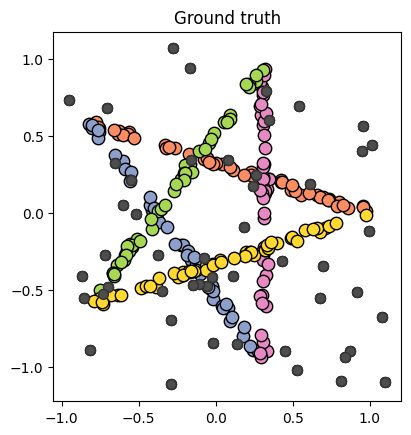

In [334]:
plt.figure(1)
display_clust(X,G, cmap)
plt.title('Ground truth')
plt.gca().set_aspect('equal')
plt.show()

In [335]:
# take a copy of X to be modified
Y = X.copy()

# define cells to contain the fitted models
currentModel = []
currentInliers = []

# minimum number of expected inliers for each
E_min = 5

cnt = 0
while cnt < kappa and Y.shape[1] >= E_min:
    # find model with ransac (save currentModel and currentInliers for visualization)
    theta_k, inliers_k = simpleRANSAC(Y, epsi, cardmss)

    # stopping criterion based on the consensus of the last model found
    if np.sum(inliers_k) < E_min:
        print("Not enough inliers found, stopping at iteration", cnt)
        break

    # save current model
    currentModel.append(theta_k)
    # save current inliers
    currentInliers.append(inliers_k)

    # remove current inliers
    Y = np.delete(Y, inliers_k, axis=1)

    # update iterations
    cnt += 1

    print("Model", cnt, "found with", np.sum(inliers_k), "inliers.")

    # additional stopping criterion based on remaining data
    if Y.shape[1] < E_min:
        print("Less than E_min points remaining, stopping.")
        break

Model 1 found with 16 inliers.
Model 2 found with 33 inliers.
Model 3 found with 43 inliers.
Model 4 found with 43 inliers.
Model 5 found with 31 inliers.


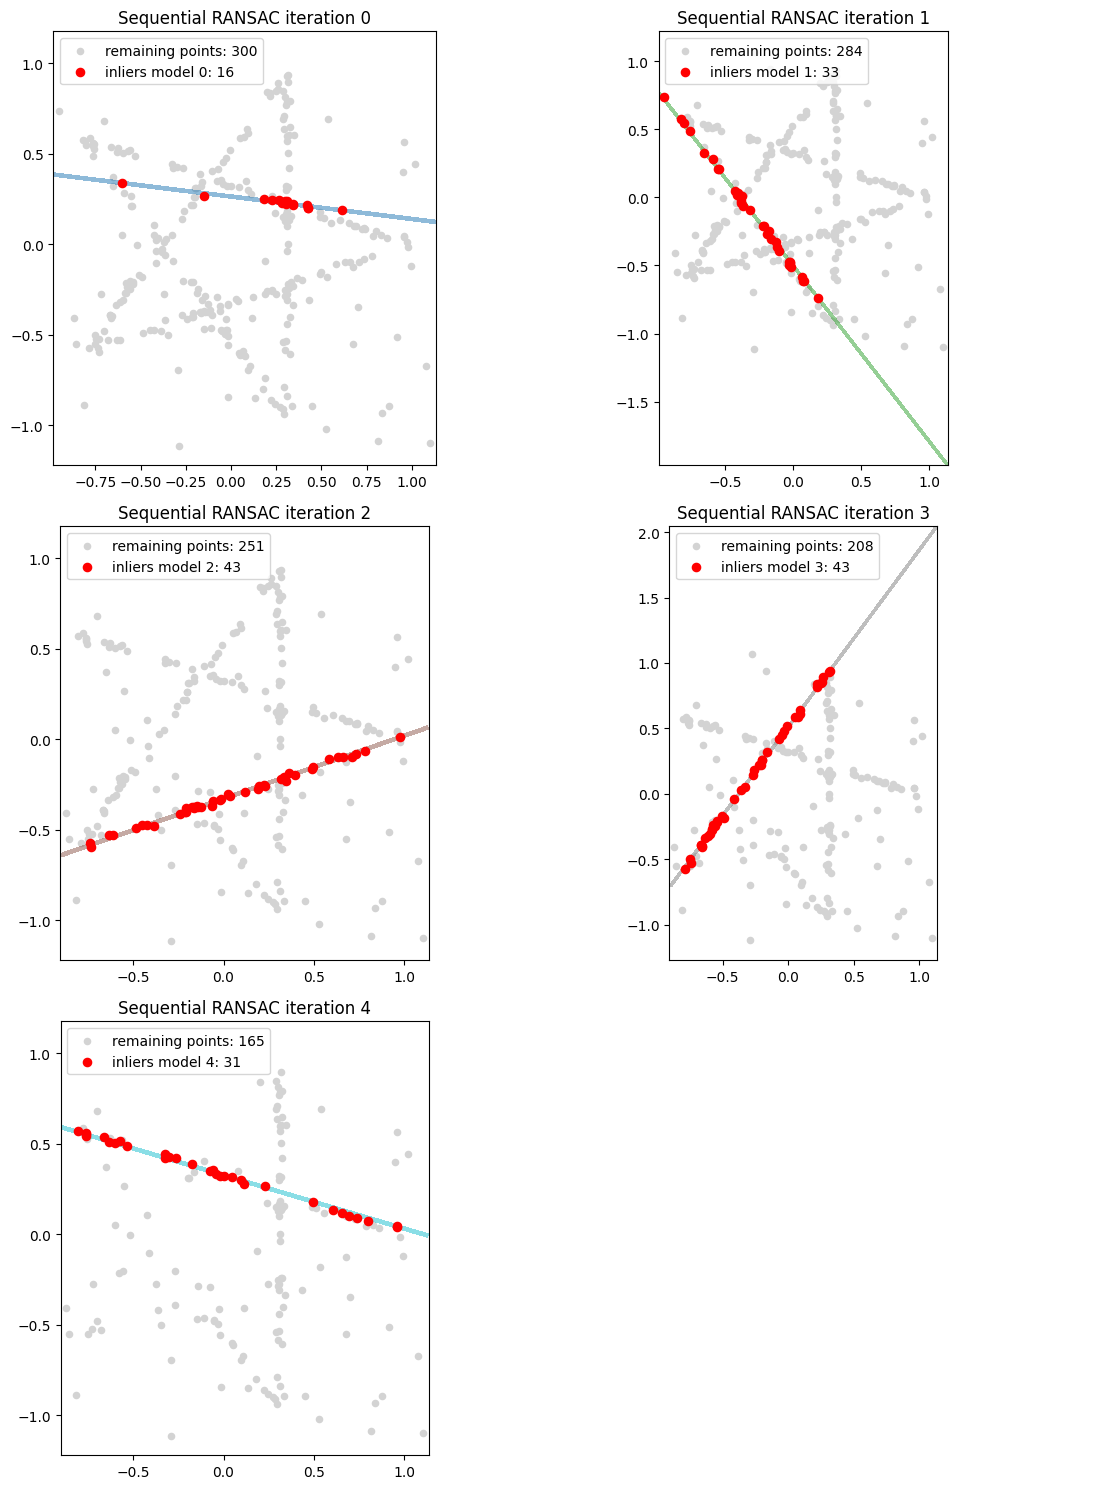

In [336]:
Y = X.copy()

# number of models actually found
n_models = len(currentModel)

# generate one color for each model
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

n_cols = 2
n_rows = int(np.ceil(kappa / n_cols))

plt.figure(figsize=(12, 5 * n_rows))

for i in range(n_models):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.gca().set_aspect('equal')

    # get current model and current inliers
    theta_i = currentModel[i]
    inliers_i = currentInliers[i]

    # color associated with current model
    color_i = colors[i]

    # plot remaining points before removing current inliers
    plt.scatter(
        Y[0, :],
        Y[1, :],
        c='lightgray',
        s=20,
        label=f'remaining points: {Y.shape[1]}'
    )

    # display a band for each model estimated
    display_band(Y, theta_i, bw, color_i)

    # plot inliers for this model
    plt.scatter(
        Y[0, inliers_i],
        Y[1, inliers_i],
        c='red',
        s=35,
        label=f'inliers model {i}: {np.sum(inliers_i)}'
    )

    plt.title(f'Sequential RANSAC iteration {i:d}')
    plt.legend(loc='upper left')

    # remove the inliers plotted from Y
    Y = np.delete(Y, inliers_i, axis=1)

# hide the unused subplot if kappa is odd
if kappa % n_cols != 0:
    plt.subplot(n_rows, n_cols, kappa + 1)
    plt.axis('off')

plt.tight_layout()
plt.show()

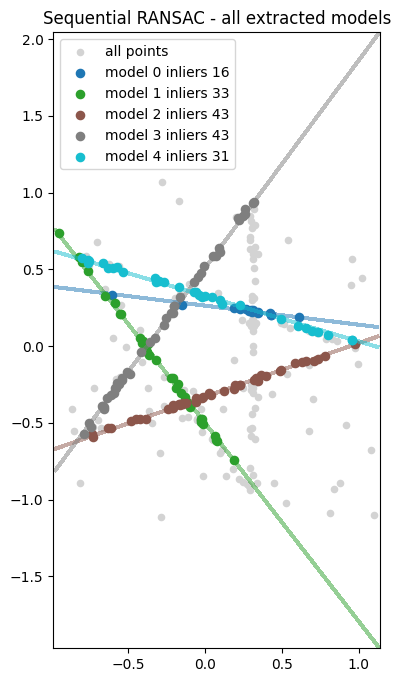

In [337]:
plt.figure(figsize=(8, 8))
plt.gca().set_aspect('equal')

# plot all original points in background
plt.scatter(
    X[0, :],
    X[1, :],
    c='lightgray',
    s=20,
    label='all points'
)

# mapping from current residual dataset Y to original dataset X
remaining_idx = np.arange(X.shape[1])

for i in range(n_models):
    theta_i = currentModel[i]
    inliers_i = currentInliers[i]
    color_i = colors[i]

    # convert inliers from residual dataset indices to original X indices
    original_inliers_i = remaining_idx[inliers_i]
    remaining_idx = np.delete(remaining_idx, inliers_i)

    # display model band on original data reference
    display_band(X, theta_i, bw, color_i)

    # plot inliers of this model on original dataset
    plt.scatter(
        X[0, original_inliers_i],
        X[1, original_inliers_i],
        color=color_i,
        s=35,
        label=f'model {i} inliers {np.sum(inliers_i)}'
    )

plt.title('Sequential RANSAC - all extracted models')
plt.legend(loc='upper left')
plt.show()

## MultiModel fitting on circle
Implement Ransac (thus run Sequential Ransac) to fit circles

In [338]:
# inlier threshold for ransac
epsi = 0.02

temp = loadmat(f'{rootfolder}/data/circle5.mat')

# data
X = temp['X']
# ground truth or label (1: normal, 0: outlier)
G = temp['G']

# model specification
# functions to fit and compute residuals are already invoked in the function
cardmss = 3 # minimum number of points required to fit a model
kappa = 10 # number of models to be extracted by sequential ransac

# plotting params
bw = 0.01
col = 'b'
temp = loadmat(f'{rootfolder}/data/cmap.mat')
cmap = temp['cmap']

# add outliers
nOut = 200

# add outlier and update groundtruth
X = addOutliersInBB(X, nOut)

# update the label, considering that X previous command has appended nOut otliers 
G = np.hstack((G.flatten(), np.zeros(nOut))).reshape(1, -1)

C:\Users\nicco\AppData\Local\Temp\ipykernel_7960\2377814344.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
C:\Users\nicco\AppData\Local\Temp\ipykernel_7960\2377814344.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


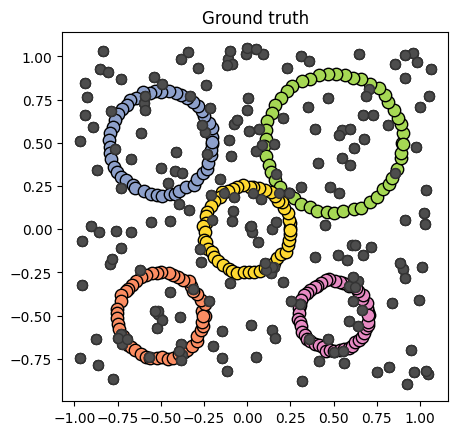

In [339]:
plt.figure(1)
display_clust(X,G, cmap)
plt.title('Ground truth')
plt.gca().set_aspect('equal')
plt.show()

In [340]:
# take a copy of X to be modified
Y = X.copy()

# define cells to contain the fitted models
currentModel = []
currentInliers = []

# minimum number of expected inliers for each
E_min = 30

cnt = 0
while cnt < kappa and Y.shape[1] >= E_min:
    # find model with ransac (save currentModel and currentInliers for visualization)
    theta_k, inliers_k = simpleRANSAC_circle(Y, epsi, cardmss)

    # stopping criterion based on the consensus of the last model found
    if np.sum(inliers_k) < E_min:
        print("Not enough inliers found, stopping at iteration", cnt)
        break

    # save current model
    currentModel.append(theta_k)
    # save current inliers
    currentInliers.append(inliers_k)

    # remove current inliers
    Y = np.delete(Y, inliers_k, axis=1)

    # update iterations
    cnt += 1

    print("Model", cnt, "found with", np.sum(inliers_k), "inliers.")

    # additional stopping criterion based on remaining data
    if Y.shape[1] < E_min:
        print("Less than E_min points remaining, stopping.")
        break
print("Total models found:", cnt)

Model 1 found with 40 inliers.
Model 2 found with 56 inliers.
Model 3 found with 56 inliers.
Model 4 found with 52 inliers.
Model 5 found with 54 inliers.
Not enough inliers found, stopping at iteration 5
Total models found: 5


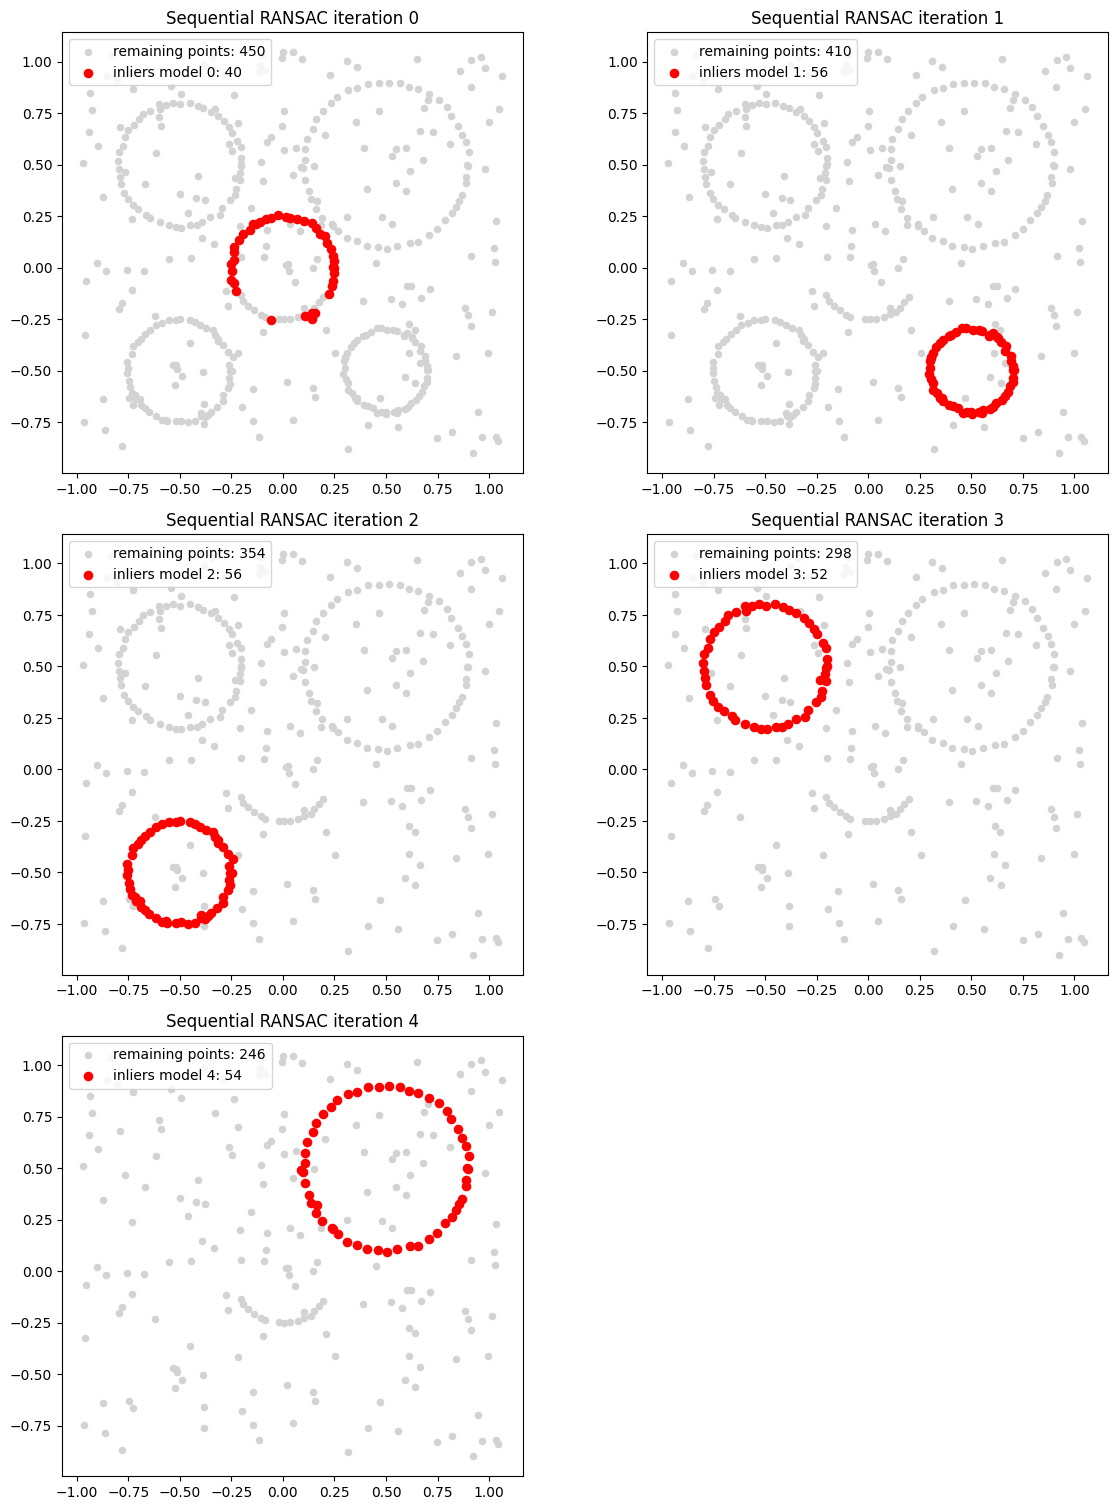

In [341]:
Y = X.copy()

# number of models actually found
n_models = len(currentModel)

# generate one color for each model
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

n_cols = 2
n_rows = int(np.ceil(kappa / n_cols))

plt.figure(figsize=(12, 5 * n_rows))

for i in range(n_models):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.gca().set_aspect('equal')

    # get current model and current inliers
    theta_i = currentModel[i]
    inliers_i = currentInliers[i]

    # color associated with current model
    color_i = colors[i]

    # plot remaining points before removing current inliers
    plt.scatter(
        Y[0, :],
        Y[1, :],
        c='lightgray',
        s=20,
        label=f'remaining points: {Y.shape[1]}'
    )

    # plot inliers for this model
    plt.scatter(
        Y[0, inliers_i],
        Y[1, inliers_i],
        c='red',
        s=35,
        label=f'inliers model {i}: {np.sum(inliers_i)}'
    )

    plt.title(f'Sequential RANSAC iteration {i:d}')
    plt.legend(loc='upper left')

    # remove the inliers plotted from Y
    Y = np.delete(Y, inliers_i, axis=1)

# hide the unused subplot if kappa is odd
if kappa % n_cols != 0:
    plt.subplot(n_rows, n_cols, kappa + 1)
    plt.axis('off')

plt.tight_layout()
plt.show()

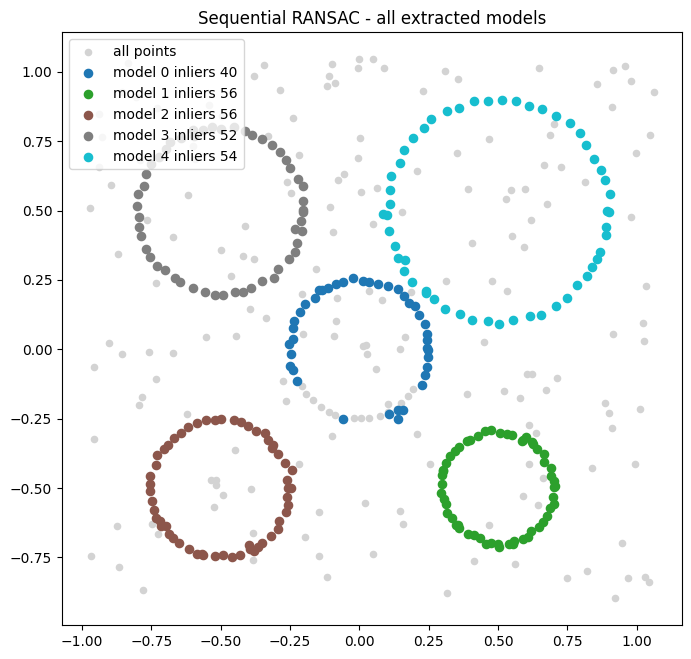

In [342]:
plt.figure(figsize=(8, 8))
plt.gca().set_aspect('equal')

# plot all original points in background
plt.scatter(
    X[0, :],
    X[1, :],
    c='lightgray',
    s=20,
    label='all points'
)

# mapping from current residual dataset Y to original dataset X
remaining_idx = np.arange(X.shape[1])

for i in range(n_models):
    theta_i = currentModel[i]
    inliers_i = currentInliers[i]
    color_i = colors[i]

    # convert inliers from residual dataset indices to original X indices
    original_inliers_i = remaining_idx[inliers_i]
    remaining_idx = np.delete(remaining_idx, inliers_i)

    # plot inliers of this model on original dataset
    plt.scatter(
        X[0, original_inliers_i],
        X[1, original_inliers_i],
        color=color_i,
        s=35,
        label=f'model {i} inliers {np.sum(inliers_i)}'
    )

plt.title('Sequential RANSAC - all extracted models')
plt.legend(loc='upper left')
plt.show()